In [1]:
# Running locally instead of Colab — no drive mount needed


Mounted at /content/drive


In [2]:
path = "../data/merged_chip_data.csv"


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path)

In [5]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [6]:
df.DATE = pd.to_datetime(df.DATE)
df['MONTH'] = df['DATE'].dt.month_name()

Now we need to work out a way of ranking how similar each potential control store is to the trial store. We
can calculate how correlated the performance of each store is to the trial store.

Let's use parameters


*   Total Sales in each month
*   Total Customers in each month


Apart from correlation, we can also calculate a standardised metric based on the absolute difference between the trial store’s performance and each control store’s performance.

Let’s write a function combining both for this so that we don’t have to calculate this for each trial store and control store pair.

In [7]:
import numpy as np

def correlation_factor(df, metric, Store_number):
    Store_numbers = [77, 86, 88]
    pre_trail_df = df.loc[pd.to_datetime('2019-03-01') > df['DATE']]
    trail_df = df.loc[(pd.to_datetime('2019-03-01') <= df['DATE']) & (df['DATE'] <= pd.to_datetime('2019 - 06 - 30'))]
    post_trail_df = df.loc[df['DATE'] > pd.to_datetime('2019 - 06 - 30')]

    if metric == 'TOT_SALES':
      all_sales = (
      pre_trail_df.groupby(['MONTH', 'STORE_NBR'])[metric]
      .sum()
      .unstack(fill_value=0)
      )

    else:
      all_sales = (
      pre_trail_df.groupby(['MONTH', 'STORE_NBR'])[metric]
      .nunique()
      .unstack(fill_value=0)
      )


    trail_stores_sales = all_sales[all_sales.columns[all_sales.columns.isin([Store_number])]]
    controlled_sales = all_sales[all_sales.columns[~all_sales.columns.isin(Store_numbers)]]

    data = np.array(trail_stores_sales)

    store = np.abs(np.mean(data[:, 0, np.newaxis] - controlled_sales, axis=0))

    magnitude_distance = 1 - ((store - np.min(store)) / (np.max(store) - np.min(store)))

    corr = all_sales.corr()[Store_number]
    corr = corr.drop([77, 86, 88], errors='ignore')

    return (magnitude_distance + corr)/2

In [8]:
metrics = ['LYLTY_CARD_NBR', 'TOT_SALES']
Stores = [77, 86, 88]
all_stores_correlation_matrices = {}

for store_num in Stores:
    current_store_metric_correlations = []
    for metric_name in metrics:
        correlation_series = correlation_factor(df, metric=metric_name, Store_number=store_num)
        current_store_metric_correlations.append(correlation_series)

    correlation_matrix_for_store = pd.concat(current_store_metric_correlations, axis=1)
    all_stores_correlation_matrices[store_num] = correlation_matrix_for_store

    print(np.mean(all_stores_correlation_matrices[store_num], axis=1).sort_values(ascending=False).index[0])


233
155
237


233, 155 and 237 are the controlled stores for trail stores 77, 86 and 88 respectively

Now that we have found control stores, let’s check visually if the drivers are indeed similar in the period
before the trial.

Let's write a function so that we can apply this function to all three sets of control and trail stores.

In [13]:
import matplotlib.pyplot as plt
def graph(df, trail_store, control_store, metric):
  Store_numbers = [77, 86, 88]
  pre_trail_df = df.loc[pd.to_datetime('2019-02-01') > df['DATE']]
  trail_df = df.loc[(pd.to_datetime('2019-02-01') <= df['DATE']) & (df['DATE'] <= pd.to_datetime('2019 - 04 - 30'))]
  post_trail_df = df.loc[df['DATE'] > pd.to_datetime('2019 - 04 - 30')]

  if metric == 'TOT_SALES':
    all_sales = (
      pre_trail_df.groupby(['MONTH', 'STORE_NBR'])[metric]
      .sum()
      .unstack(fill_value=0)
      )

  else:
    all_sales = (
      pre_trail_df.groupby(['MONTH', 'STORE_NBR'])[metric]
      .nunique()
      .unstack(fill_value=0)
      )

  stores_for_plot_df = all_sales[[trail_store, control_store]]
  all_excluded_from_average = list(set(Store_numbers + [control_store]))

  controlled_sales = all_sales[all_sales.columns[~all_sales.columns.isin(all_excluded_from_average)]]
  other_store_avg = controlled_sales.mean(axis=1)

  month_order = [
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
    'January'
  ]

  stores_for_plot_df = stores_for_plot_df.reindex(month_order)
  other_store_avg = other_store_avg.reindex(month_order)

  plt.figure(figsize=(10, 6))


  plt.plot(
    stores_for_plot_df.index,
    stores_for_plot_df[trail_store],
    label='Trial',
    linewidth=2
  )


  plt.plot(
    stores_for_plot_df.index,
    stores_for_plot_df[control_store],
    label='Control',
    linewidth=2
  )


  plt.plot(
    other_store_avg.index,
    other_store_avg,
    label='Other stores',
    linewidth=2
  )

  plt.title((metric + " by month"), fontsize=18)
  plt.xlabel("Month of operation", fontsize=14)
  plt.ylabel(metric, fontsize=14)

  plt.legend(title="Store_type")
  plt.grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

## **STORE 77:**

We’ll look at total sales first. For 77 and 233

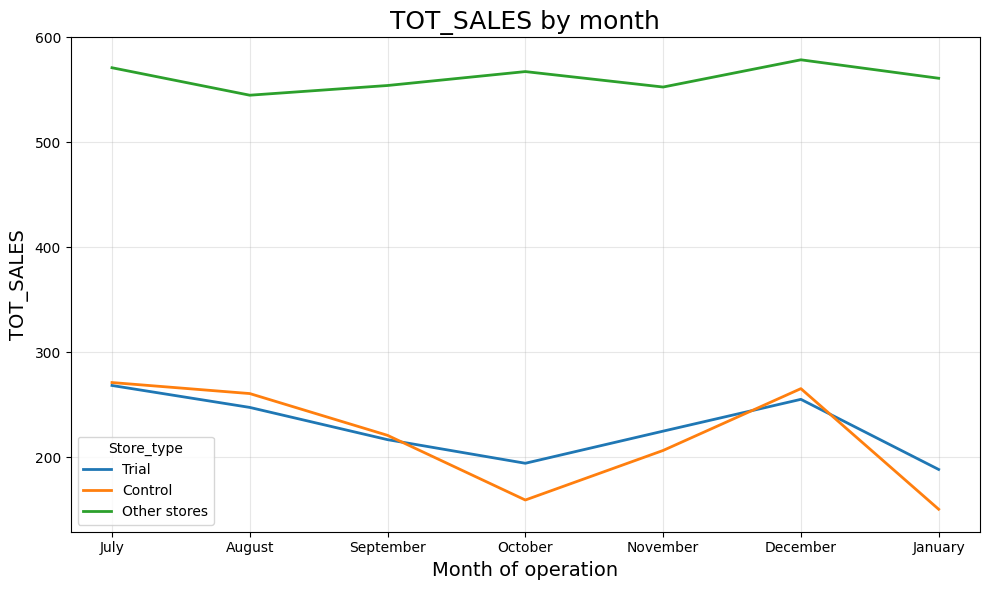

In [14]:
graph(df, trail_store = 77, control_store = 233, metric= 'TOT_SALES')

Next, number of customers

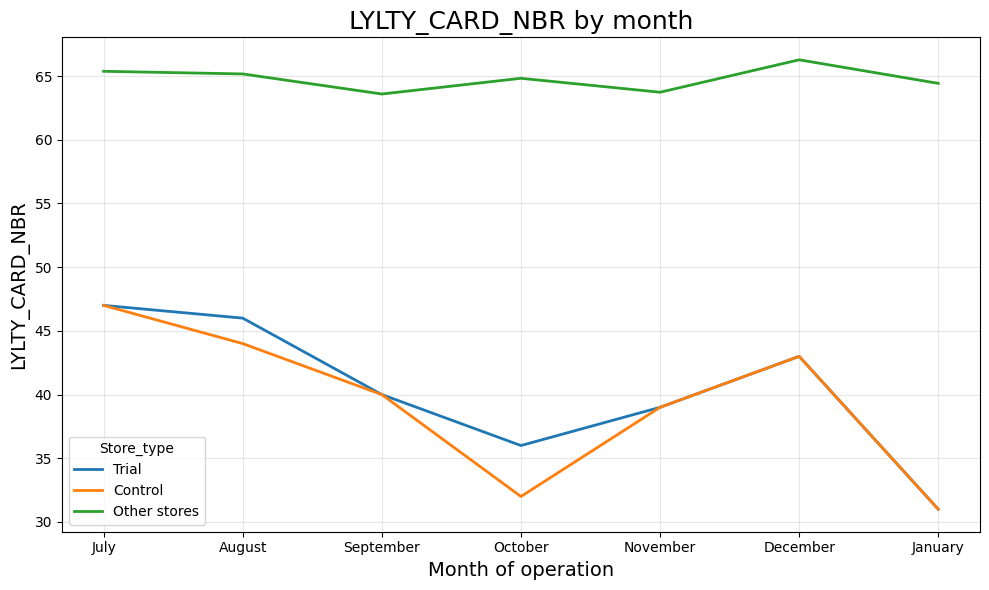

In [15]:
graph(df, trail_store = 77, control_store = 233, metric= 'LYLTY_CARD_NBR')

In the trial period e want to see if there has been an
uplift in overall chip sales.

We’ll write a function to:

*   scale the control store’s sales to a level similar to the control for any differences between the two stores outside of the trial period.


*   To create a more visual version of this by plotting the sales of the control store, the sales of the trial stores
and the 95th percentile value of sales of the control store.

*   Also to see if the difference is significant!

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def a(df, metric, trail_store, control_store):

    # Split data
    pre_trail_df = df[df['DATE'] < pd.to_datetime('2019-02-01')]
    trail_df = df[
        (df['DATE'] >= pd.to_datetime('2019-02-01')) &
        (df['DATE'] <= pd.to_datetime('2019-04-30'))
    ]

    # ==========================
    # PRE-TRIAL SALES
    # ==========================
    if metric == 'TOT_SALES':
        pre_trial_all = (
            pre_trail_df
            .groupby(['MONTH', 'STORE_NBR'])[metric]
            .sum()
            .unstack(fill_value=0)
        )
    else:
        pre_trial_all = (
            pre_trail_df
            .groupby(['MONTH', 'STORE_NBR'])[metric]
            .nunique()
            .unstack(fill_value=0)
        )

    pre_trial_trial = pre_trial_all[[trail_store]]
    pre_trial_control = pre_trial_all[[control_store]]

    # Scaling factor
    scaling_factor = (
        pre_trial_trial.mean().iloc[0] /
        pre_trial_control.mean().iloc[0]
    )

    # Scale control store
    scaled_pre_trial_control = pre_trial_control * scaling_factor

    pre_trial_trial = pre_trial_trial.to_numpy()
    scaled_pre_trial_control = scaled_pre_trial_control.to_numpy()

    # Percentage difference
    pre_trial_percentage_diff = (
        np.abs(pre_trial_trial - scaled_pre_trial_control)
        / scaled_pre_trial_control
    )

    # Standard deviation of pre-trial differences
    std_dev = pre_trial_percentage_diff.std(ddof=1)

    # ==========================
    # SALES OVER ALL MONTHS (FOR PLOTTING)
    # =========================

    if metric == 'TOT_SALES':
        all_sales = (
            df.groupby(['MONTH', 'STORE_NBR'])[metric]
              .sum()
              .unstack(fill_value=0)
        )
    else:
        all_sales = (
            df.groupby(['MONTH', 'STORE_NBR'])[metric]
              .nunique()
              .unstack(fill_value=0)
        )

    trial_plot = all_sales[[trail_store]].rename(columns={trail_store: "Trial"})
    control_plot = all_sales[[control_store]].rename(columns={control_store: "Control"})

    # Confidence interval
    upper = control_plot * (1 + 2 * std_dev)
    lower = control_plot * (1 - 2 * std_dev)


    # Order of months
    month_order = [
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
    'January',
    'February',
    'March',
    'April',
    'May',
    'June'
    ]

    # Sort according to chronological order
    control_plot.index = pd.Categorical(
    control_plot.index,
    categories=month_order,
    ordered=True
    )

    trial_plot.index = pd.Categorical(
    trial_plot.index,
    categories=month_order,
    ordered=True
    )

    upper.index = pd.Categorical(
    upper.index,
    categories=month_order,
    ordered=True
    )

    lower.index = pd.Categorical(
    lower.index,
    categories=month_order,
    ordered=True
    )

    control_plot = control_plot.sort_index()
    trial_plot = trial_plot.sort_index()
    upper = upper.sort_index()
    lower = lower.sort_index()

    # Plot
    plt.figure(figsize=(11,6))

    plt.plot(control_plot.index.astype(str),
         control_plot.iloc[:,0],
         color='red',
         linewidth=2,
         label='Control')

    plt.plot(lower.index.astype(str),
         lower.iloc[:,0],
         color='green',
         linewidth=2,
         label='Control 5th % confidence interval')

    plt.plot(upper.index.astype(str),
         upper.iloc[:,0],
         color='cyan',
         linewidth=2,
         label='Control 95th % confidence interval')

    plt.plot(trial_plot.index.astype(str),
         trial_plot.iloc[:,0],
         color='purple',
         linewidth=2,
         label='Trial')

    # Shade trial period (February–April)
    plt.axvspan(7, 9, color='black', alpha=0.5)

    plt.title(f"{metric} by month", fontsize=20)
    plt.xlabel("Month of operation", fontsize=14)
    plt.ylabel(metric, fontsize=14)

    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()


    # Start y-axis from 0
    plt.ylim(bottom=0)

    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    plt.show()


    # ==========================
    # TRIAL PERIOD (FOR T-VALUES)
    # ==========================

    if metric == 'TOT_SALES':
        trial_all = (
            trail_df
            .groupby(['MONTH', 'STORE_NBR'])[metric]
            .sum()
            .unstack(fill_value=0)
        )
    else:
        trial_all = (
            trail_df
            .groupby(['MONTH', 'STORE_NBR'])[metric]
            .nunique()
            .unstack(fill_value=0)
        )

    trial_sales = trial_all[[trail_store]]
    control_sales = trial_all[[control_store]]

    months = trial_sales.index

    scaled_control_sales = control_sales * scaling_factor

    trial_sales = trial_sales.to_numpy()
    scaled_control_sales = scaled_control_sales.to_numpy()

    percentage_diff = (
        np.abs(trial_sales - scaled_control_sales)
        / scaled_control_sales
    )

    t_values = percentage_diff / std_dev

    result = pd.DataFrame({
        "MONTH": months,
        "T_VALUE": t_values.flatten()
    })

    from scipy.stats import t
    critical_t = t.ppf(0.95, df=7)

    print(f"Critical t-value: {critical_t:.6f}")

    return result

Now we will apply this function to Total sales

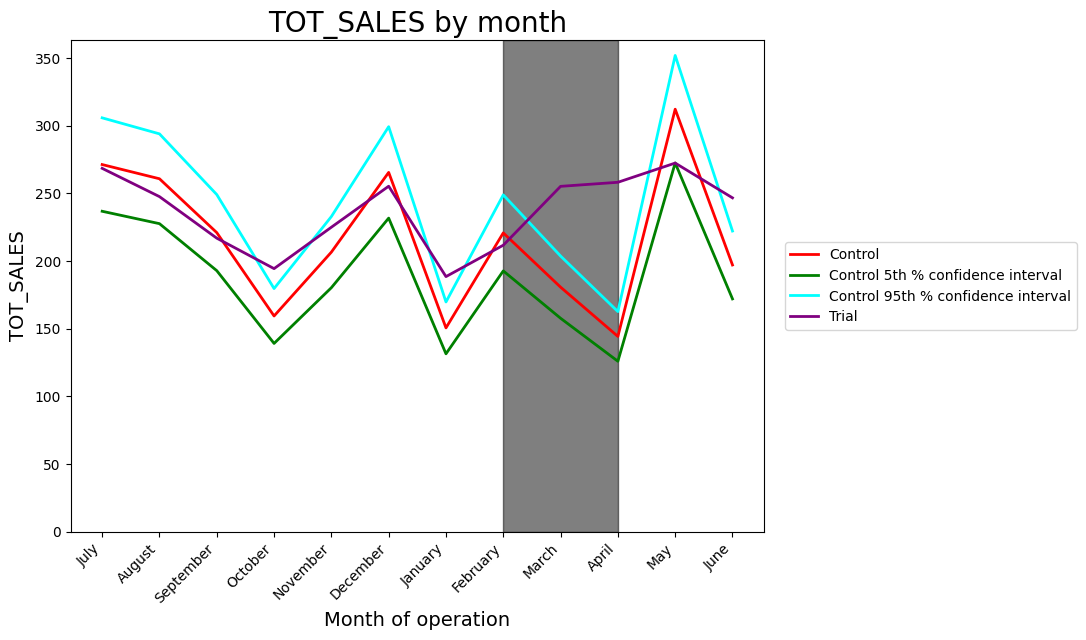

Critical t-value: 1.894579


,MONTH,T_VALUE
0,April,11.336505
1,February,1.223912
2,March,5.633494


In [113]:
a(df, metric= 'TOT_SALES', trail_store=77, control_store= 233)

We can observe that the t-value is much larger than the 95th percentile value of the t-distribution for March
and April - i.e. the increase in sales in the trial store in March and April is statistically greater than in the
control store.

The results show that the trial in store 77 is significantly different to its control store in the trial period as
the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the
three trial months.

Let’s have a look at assessing this for number of customers as well

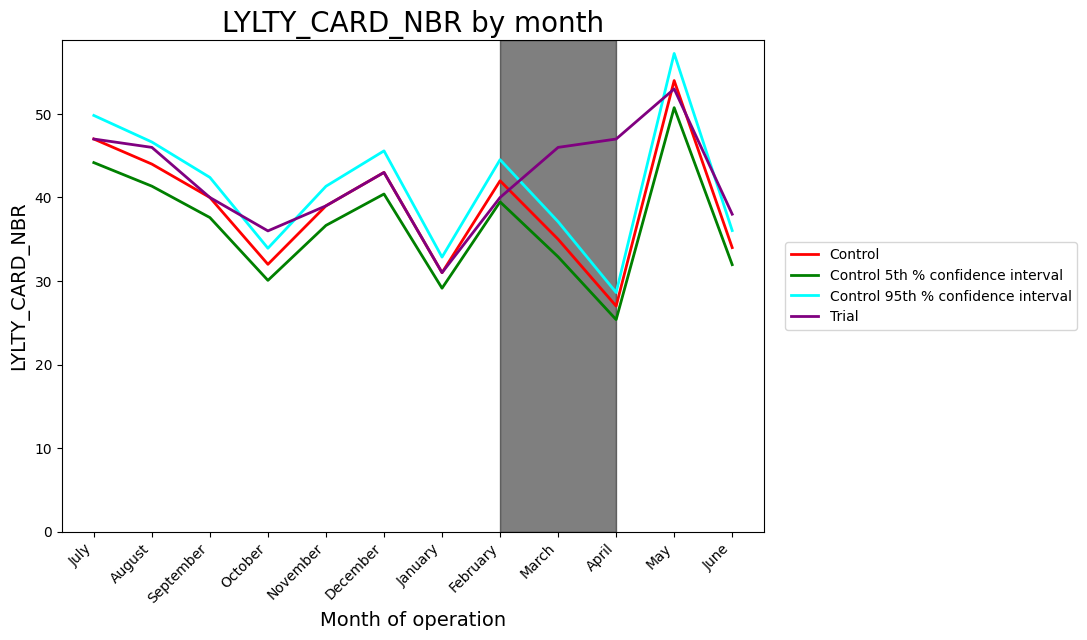

Critical t-value: 1.894579


,MONTH,T_VALUE
0,April,23.422793
1,February,2.259470
2,March,9.530240


In [114]:
a(df, metric= 'LYLTY_CARD_NBR', trail_store=77, control_store= 233)

Let’s repeat assessing the impact of the trial for each of the other two trial
stores.

## **TRAIL STORE 86:**

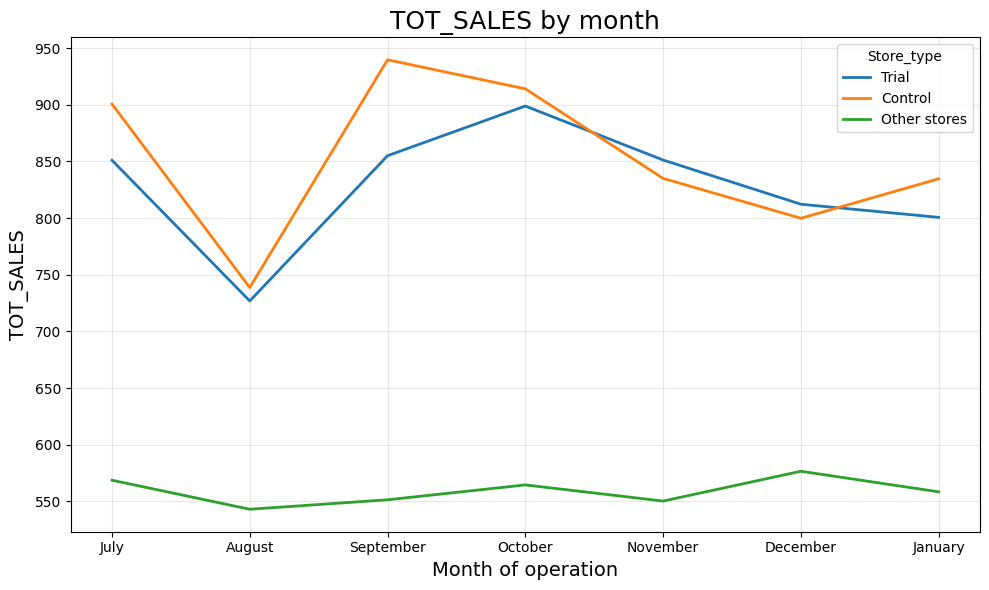

In [115]:
graph(df, trail_store = 86, control_store = 155, metric= 'TOT_SALES')

Great, sales are trending in a similar way.

Next, number of customers

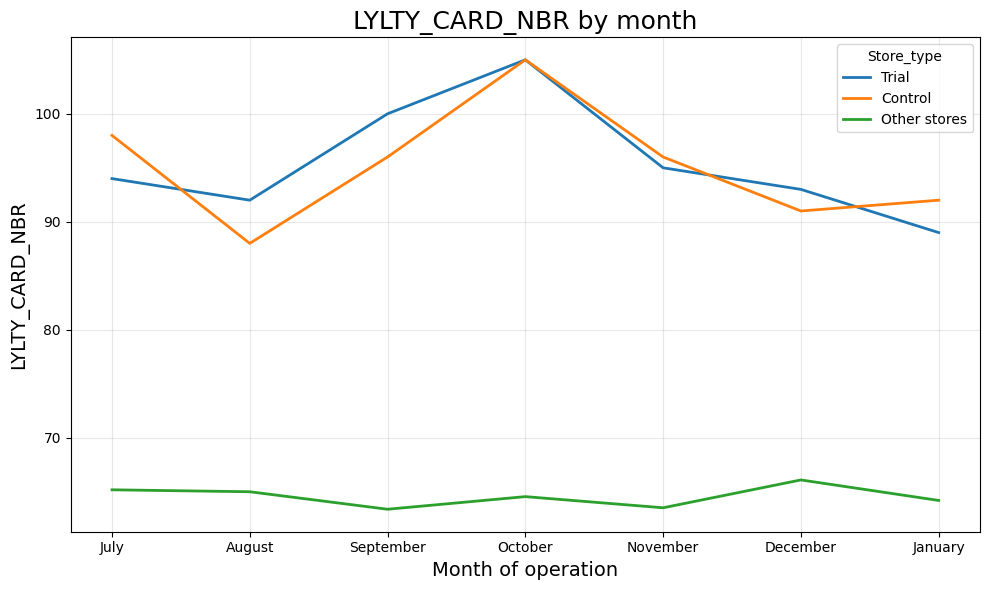

In [116]:
graph(df, trail_store = 86, control_store = 155, metric= 'LYLTY_CARD_NBR')

Good, the trend in number of customers is also similar.

Let’s now assess the impact of the trial on sales.

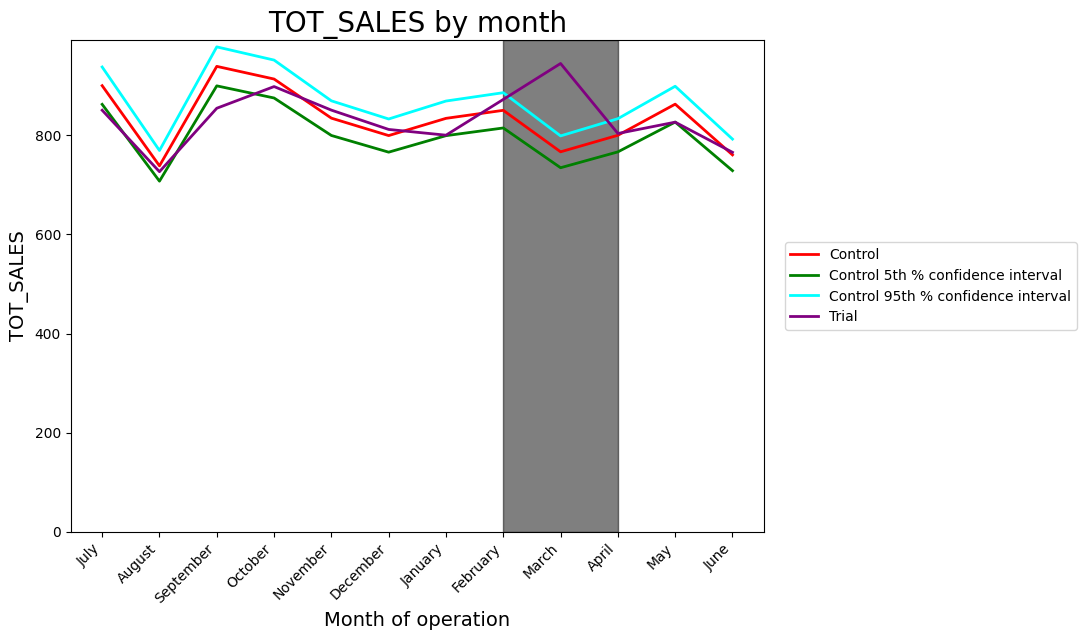

Critical t-value: 1.894579


,MONTH,T_VALUE
0,April,1.593697
1,February,2.642804
2,March,12.796638


In [117]:
a(df, metric= 'TOT_SALES', trail_store=86, control_store= 155)

The results show that the trial in store 86 is not significantly different to its control store in the trial period
as the trial store performance lies inside the 5% to 95% confidence interval of the control store in two of the
three trial months.

Let’s have a look at assessing this for number of customers as well.

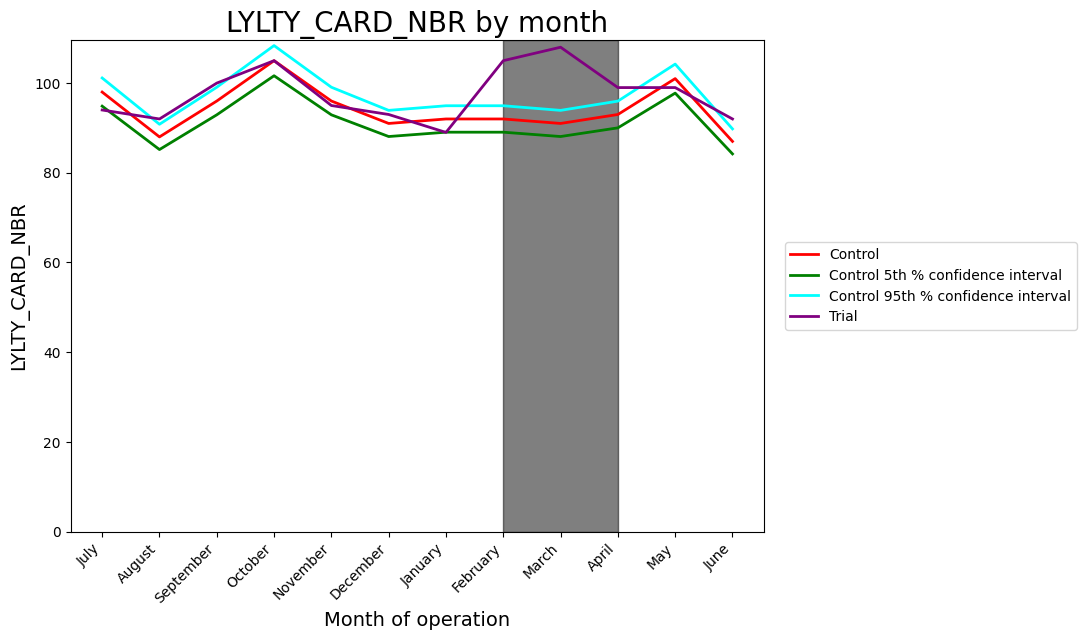

Critical t-value: 1.894579


,MONTH,T_VALUE
0,April,3.827618
1,February,8.605720
2,March,11.437481


In [119]:
a(df, metric= 'LYLTY_CARD_NBR', trail_store=86, control_store= 155)

It looks like the number of customers is significantly higher in all of the three months. This seems to
suggest that the trial had a significant impact on increasing the number of customers in trial store 86 but
as we saw, sales were not significantly higher. We should check with the Category Manager if there were
special deals in the trial store that were may have resulted in lower prices, impacting the results.

## **TRAIL STORE 88:**

Again, let’s check visually if the drivers are indeed similar in the period before the trial.
\
We’ll look at total sales first.

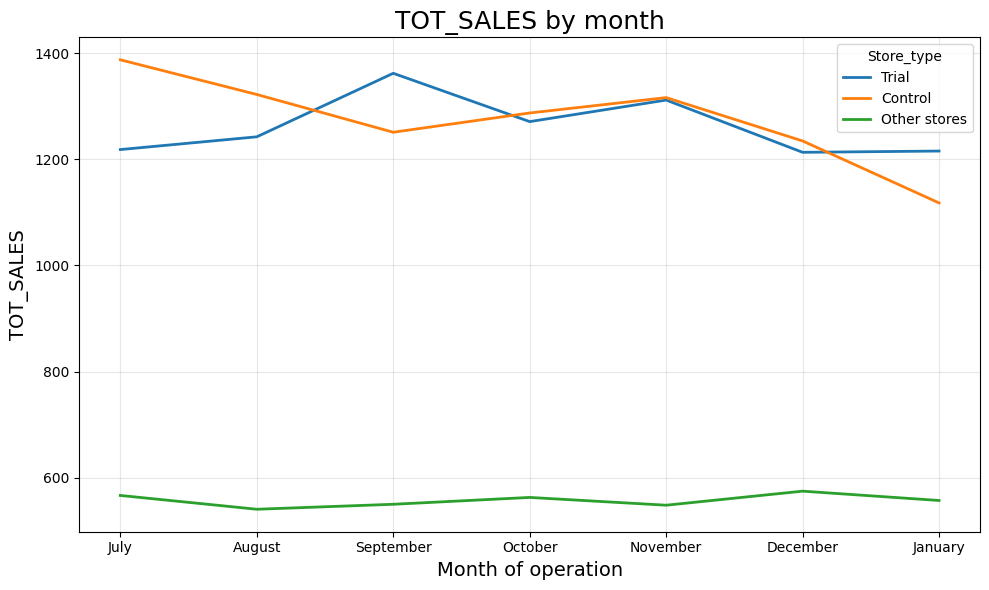

In [120]:
graph(df, trail_store = 88, control_store = 237, metric= 'TOT_SALES')

Great, the trial and control stores have similar total sales

Next, number of customers.

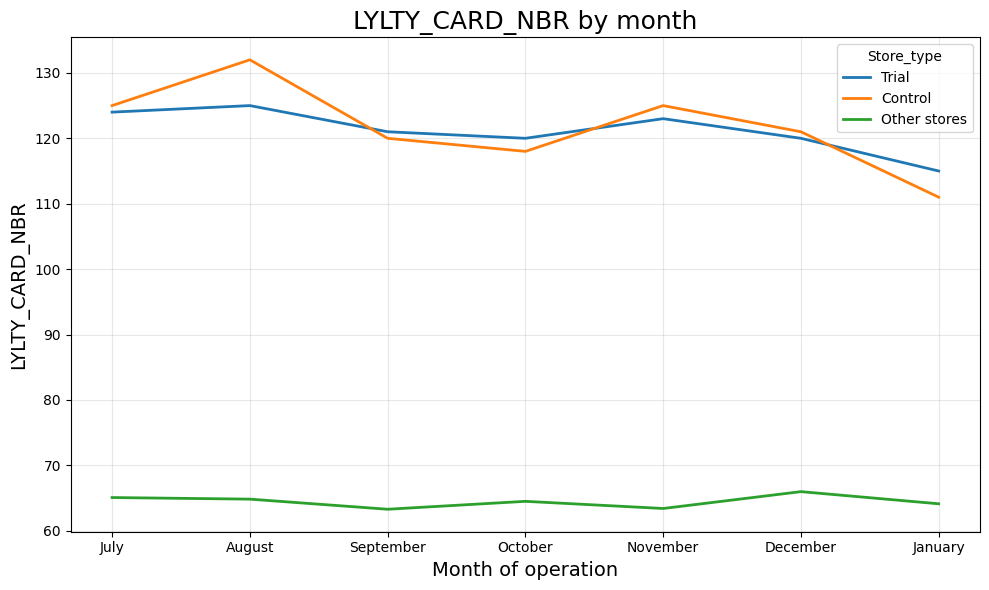

In [121]:
graph(df, trail_store = 88, control_store = 237, metric= 'LYLTY_CARD_NBR')

Total number of customers of the control and trial stores are also similar.

Let’s now assess the impact of the trial on sales.

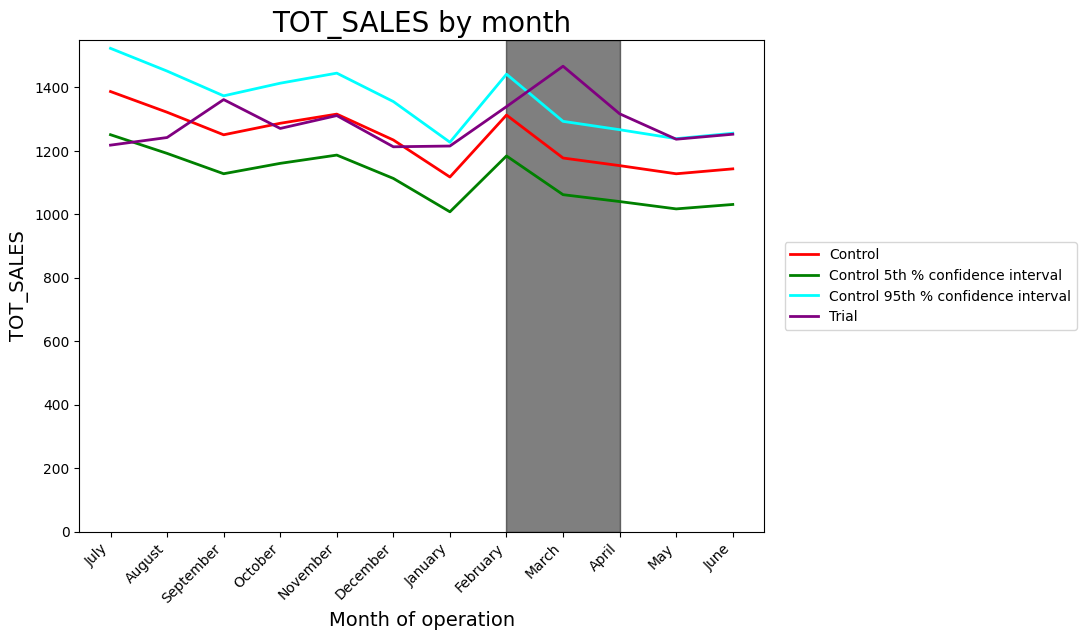

Critical t-value: 1.894579


,MONTH,T_VALUE
0,April,3.102824
1,February,0.606487
2,March,5.243910


In [122]:
a(df, metric= 'TOT_SALES', trail_store=88, control_store= 237)

The results show that the trial in store 88 is significantly different to its control store in the trial period as the
trial store performance lies outside of the 5% to 95% confidence interval of the control store in two of the
three trial months.

Let’s have a look at assessing this for number of customers as well.

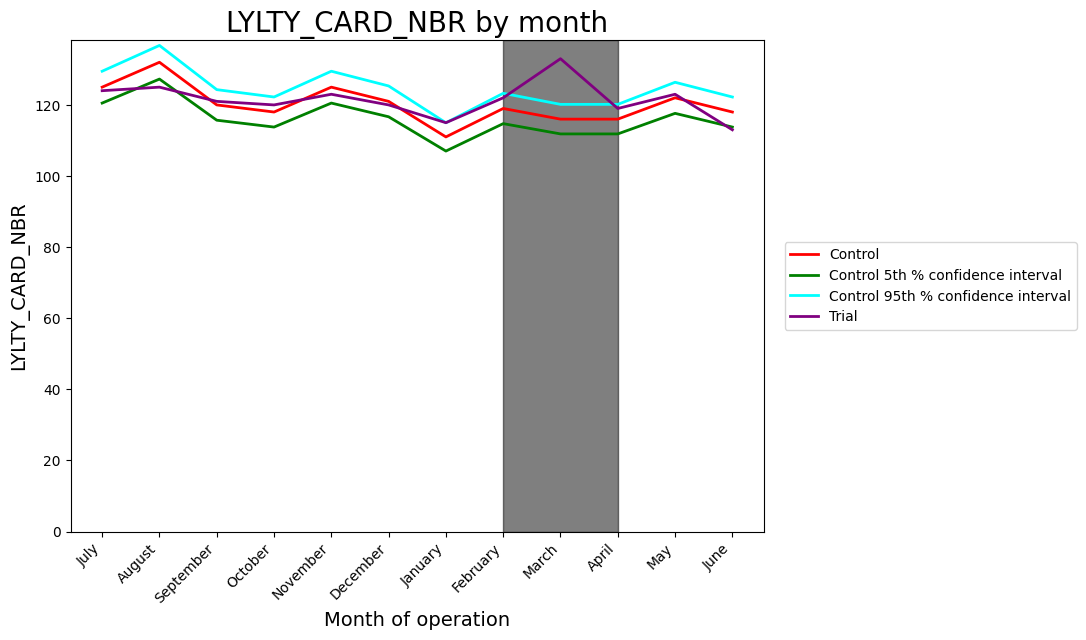

Critical t-value: 1.894579


,MONTH,T_VALUE
0,April,1.713669
1,February,1.677105
2,March,8.482095


In [123]:
a(df, metric= 'LYLTY_CARD_NBR', trail_store=88, control_store= 237)

Total number of customers in the trial period for the trial store is significantly higher than the control store
for two out of three months, which indicates a positive trial effect.

## **CONCLUSION:**



*   We’ve found control stores 233, 155, 237 for trial stores 77, 86 and 88 respectively.
*   The results for trial stores 77 and 88 during the trial period show a significant difference in at least two of the
three trial months but this is not the case for trial store 86. We can check with the client if the implementation
of the trial was different in trial store 86 but overall, the trial shows a significant increase in sales.



*   Now that
we have finished our analysis, we can prepare our presentation to the Category Manager.




